# Data Cleaning

Before building the ride duration prediction model, the dataset must be cleaned to remove invalid, inconsistent, and noisy records. This helps improve data quality and model performance.


## Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Define Helper Functions

To avoid repeating the same code, a reusable function is created to remove outliers using the Interquartile Range (IQR) method.


In [13]:
def remove_outliers_iqr(df, column, show_plot=True):
    # Original data
    original_data = df[column]

    # IQR calculation
    Q1 = original_data.quantile(0.25)
    Q3 = original_data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filtered data
    filtered_df = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ]

    if show_plot:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        axes[0].boxplot(original_data)
        axes[0].set_title(f'{column} (Before IQR)')

        axes[1].boxplot(filtered_df[column])
        axes[1].set_title(f'{column} (After IQR)')

        plt.suptitle(f'Outlier Removal for {column}')
        plt.tight_layout()
        plt.show()

    return filtered_df

## Load the Dataset

In [14]:
df = pd.read_csv("../data/student_version.csv")
original_len = len(df)
df.head()

,record_key,carrier_code,start_time,end_time,rider_total,start_xcoord,start_ycoord,end_xcoord,end_ycoord,save_forward_marker,elapsed_seconds
0,rid2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,rid2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,rid3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,rid3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,rid2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


## Handle missing values 
Handle missing values to ensure the stability and reliability of machine learning models.

In [15]:
initial_rows = len(df)

df.dropna(inplace=True)

print(f"Missing values handling: {initial_rows - len(df)} rows containing NaN removed.")


Missing values handling: 0 rows containing NaN removed.


## Remove Duplicate Records

Duplicate trips can bias the model and should be removed.
Identify and remove global duplicate records and duplicates based on the trip identifier key.

In [16]:
# record_key is expected to be unique for each trip

initial_rows = len(df)

df = df.drop_duplicates(subset=['record_key'])

print(
    f"Removed {initial_rows - len(df)} duplicate trip records."
)

Removed 0 duplicate trip records.


## Abnormal Rider Total
Trips with zero passengers are imputed with a value of 1 instead of being removed.

Passenger count fix:
  - 0 rows with negative passenger counts removed.
  - 60 rows with zero passengers imputed to 1.


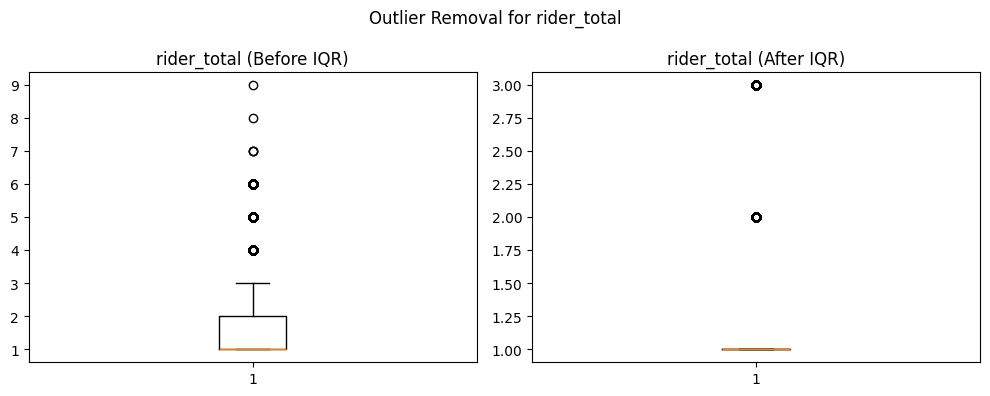

In [17]:
if 'rider_total' in df.columns:
    zero_count = (df['rider_total'] == 0).sum()
    negative_count = (df['rider_total'] < 0).sum()

    # Remove rows with negative rider counts
    df = df[df['rider_total'] >= 0]

    # Replace zero rider counts with 1
    df['rider_total'] = df['rider_total'].replace(0, 1)

    print(f"Passenger count fix:")
    print(f"  - {negative_count} rows with negative passenger counts removed.")
    print(f"  - {zero_count} rows with zero passengers imputed to 1.")

remove_outliers_iqr(df, 'rider_total');

The `rider_total` feature represents a discrete count variable rather than a continuous measurement. Therefore, the IQR method was not applied.

Instead, invalid values (negative rider counts) were removed.

## Clean Trip Duration
Remove trip duration outliers using the Interquartile Range (IQR) statistical method.
Both lower and upper bounds are determined mathematically.

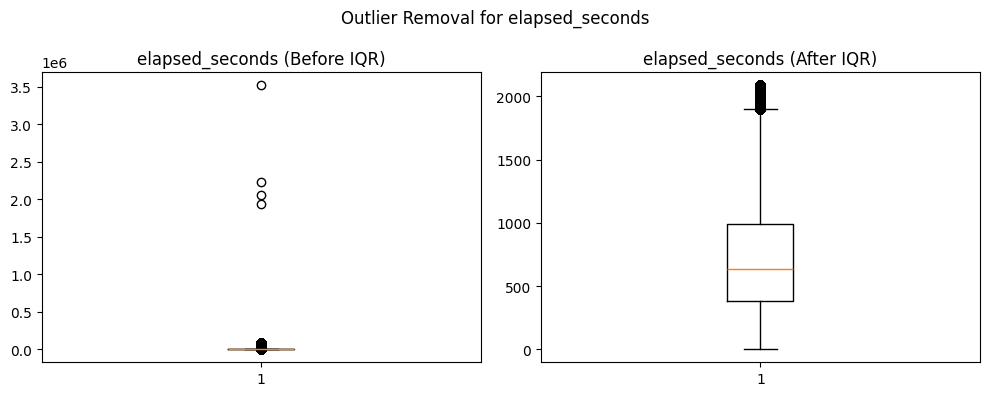

Trip duration filter (Full IQR): 74220 rows with statistical outliers removed.


In [18]:
initial_rows = len(df)

df = remove_outliers_iqr(df, 'elapsed_seconds')

print(f"Trip duration filter (Full IQR): {initial_rows - len(df)} rows with statistical outliers removed.")


## Validate Geographic Coordinates

The coordinate columns represent geographic locations:

- `xcoord` = Longitude
- `ycoord` = Latitude

Valid coordinates must satisfy:

- Latitude: -90 to 90
- Longitude: -180 to 180


In [19]:
initial_rows = len(df)

df = df[
    (df['start_ycoord'].between(-90, 90)) &
    (df['end_ycoord'].between(-90, 90)) &
    (df['start_xcoord'].between(-180, 180)) &
    (df['end_xcoord'].between(-180, 180))
]

print(f"Geographic filter: {initial_rows - len(df)} noisy rows removed.")

Geographic filter: 0 noisy rows removed.


In [20]:
print(f"Data cleaning completed. \n Final number of rows: {len(df)} \n Deleted rows in the process: {original_len - len(df)}")

Data cleaning completed. 
 Final number of rows: 1384424 
 Deleted rows in the process: 74220


In [21]:
df.to_csv("../data/clean_data.csv", index=False)